# Notebook 4: Graph Engine Validation
Goal: Validate NetworkX graph construction, Dijkstra routing, and scenario simulation.

In [1]:
import sys
import os
import time
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED_DIR = '../data/processed/'
print('Environment ready.')

Environment ready.


## 1. Build / Load Graph Cache

In [2]:
from src.graph.builder import build_all_graphs, load_graphs_cache

# load_graphs_cache() loads pre-built graphs from data/processed/graphs_cache.pkl
# If cache does not exist, call build_all_graphs() to create it.
try:
    graphs = load_graphs_cache()
    print('Loaded graphs from cache.')
except FileNotFoundError:
    print('Cache not found — building all graphs...')
    graphs = build_all_graphs(save_cache=True)
    print('Done building graphs.')

print(f'\nNumber of (year, product_code) graph snapshots: {len(graphs)}')

# Report a sample of graph sizes
print('\nSample graph sizes:')
for i, (key, G) in enumerate(graphs.items()):
    print(f'  {key}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
    if i >= 4:
        print('  ...')
        break

Loaded graphs from cache.

Number of (year, product_code) graph snapshots: 35

Sample graph sizes:
  (2016, 8517): 222 nodes, 18020 edges
  (2016, 2106): 221 nodes, 11390 edges
  (2016, 3304): 219 nodes, 10854 edges
  (2016, 9404): 220 nodes, 9728 edges
  (2016, 6109): 222 nodes, 12595 edges
  ...


## 2. Toy Graph Unit Tests

In [3]:
# Build a simple 3-node directed graph A -> B -> C
# Edge A->C also exists but with higher weight to force A->B->C as Dijkstra solution

G_toy = nx.DiGraph()
G_toy.add_edge('A', 'B', weight=1.0, lead_time=5)
G_toy.add_edge('B', 'C', weight=1.0, lead_time=5)
G_toy.add_edge('A', 'C', weight=10.0, lead_time=20)  # more expensive direct route

# Run Dijkstra
shortest_path = nx.dijkstra_path(G_toy, 'A', 'C', weight='weight')
shortest_cost = nx.dijkstra_path_length(G_toy, 'A', 'C', weight='weight')

print(f'Dijkstra path A->C: {shortest_path}')
print(f'Dijkstra cost:      {shortest_cost}')

# Assertions
assert shortest_path == ['A', 'B', 'C'], f'Expected [A, B, C], got {shortest_path}'
assert abs(shortest_cost - 2.0) < 1e-9, f'Expected cost 2.0, got {shortest_cost}'
print('\nToy graph unit test: PASS')

# Test no-path case
G_toy2 = nx.DiGraph()
G_toy2.add_edge('A', 'B', weight=1.0)
try:
    nx.dijkstra_path(G_toy2, 'A', 'C', weight='weight')
    print('No-path exception test: FAIL (should have raised)')
except nx.NetworkXNoPath:
    print('No-path exception test: PASS')
except nx.NodeNotFound:
    print('No-path exception test: PASS (node not found)')

Dijkstra path A->C: ['A', 'B', 'C']
Dijkstra cost:      2.0

Toy graph unit test: PASS
No-path exception test: PASS


## 3. Baseline Routing Demo

In [5]:
from src.graph.routing import find_k_routes

G = graphs.get((2021, 8517))
if G is None:
    # Fallback: use any available graph
    key = list(graphs.keys())[0]
    G = graphs[key]
    print(f'Graph (2021, 8517) not found. Using {key} instead.')
else:
    print('Loaded graph: (2021, HS 8517 — Telephones/Communication Equipment)')

print(f'Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.')

# Find top-3 routes from China to Germany
ORIGIN = 'China'
DEST   = 'Germany'
routes = find_k_routes(G, ORIGIN, DEST, k=3)

print(f'\nTop-3 routes: {ORIGIN} → {DEST} (Year 2021, HS 8517)\n')
for i, route in enumerate(routes, 1):
    path        = route.path
    cost        = route.cost
    lead_time   = route.lead_time_days
    print(f'  Route {i}:')
    print(f'    Path:             {" → ".join(path)}')
    print(f'    Cost (freight):   {cost:.4f}')
    print(f'    Lead time (days): {lead_time:.1f}')
    print(f'    Confidence:       {route.confidence_score:.5f}')
    print(f'    confidence_breakdown: {route.confidence_breakdown}')
    print()

Loaded graph: (2021, HS 8517 — Telephones/Communication Equipment)
Graph has 222 nodes and 18020 edges.

Top-3 routes: China → Germany (Year 2021, HS 8517)

  Route 1:
    Path:             China → Germany
    Cost (freight):   0.1220
    Lead time (days): 28.6
    Confidence:       0.60201
    confidence_breakdown: {'confidence_score': 0.6020099999999999, 'data_confidence': 1.0, 'connectivity_confidence': 0.007, 'hop_penalty': 0.5, 'support_ratio': 1.0, 'observed_edges': 1, 'historical_supported_edges': 0, 'unsupported_predicted_edges': 0, 'total_edges': 1, 'avg_lsci': 0.67}

  Route 2:
    Path:             China → Dominican Republic → Germany
    Cost (freight):   0.1256
    Lead time (days): 49.9
    Confidence:       0.46814
    confidence_breakdown: {'confidence_score': 0.4681366666666667, 'data_confidence': 0.8, 'connectivity_confidence': 0.005, 'hop_penalty': 0.333, 'support_ratio': 0.8, 'observed_edges': 1, 'historical_supported_edges': 1, 'unsupported_predicted_edges': 0, 'to

## 4. Chokepoint Scenario: Suez Canal Closure

The graph uses **country-level bilateral freight rates** (observed + ML-predicted).  
Direct edges (e.g. China → Germany) already encode the all-in cost of the voyage — including the Suez Canal toll — so simply removing the Egypt node has no effect on these direct routes.

The economically correct way to simulate a Suez Canal closure is to apply a  
**Cape of Good Hope surcharge** to all edges that cross the Suez corridor  
(i.e. one endpoint in Asia/Oceania, the other in Europe/Americas).

**Methodology**  
Geographic calculation (haversine waypoints):  
- Via Suez: Shanghai → Singapore → Gulf of Aden → Suez → Hamburg ≈ **16 100 km (~24 days)**  
- Via Cape of Good Hope: Shanghai → Singapore → Cape → Hamburg ≈ **23 300 km (~35 days)**  
- Extra distance: **+7 200 km (+45%)** → cost multiplier **1.45×**, lead-time premium **+10.8 days**

A Suez-crossing edge is any edge where the two country centroids straddle the  
canal longitude (32 °E): one country east of 32 °E, the other west.

=== Scenario: Suez Canal Closure ===

Building Suez-closed graph (Cape of Good Hope cost multiplier 1.446×)...
  Surcharge applied to 6058 Suez-crossing edges.

Cost impact of Suez Canal closure on Asia–Europe corridors:
                            Corridor  Baseline Cost  Suez-Closed Cost  Cost Premium (%)  Est. Extra Days Crosses Suez
                     China → Germany          0.122            0.1764              44.6             10.8          Yes
China → Netherlands (Kingdom of the)          0.171            0.2473              44.6             10.8          Yes
                     India → Germany          0.077            0.1113              44.6             10.8          Yes
         Republic of Korea → Germany          0.049            0.0709              44.6             10.8          Yes
                     Japan → Germany          0.169            0.2444              44.6             10.8          Yes
                 Singapore → Germany          0.097            0.1403  

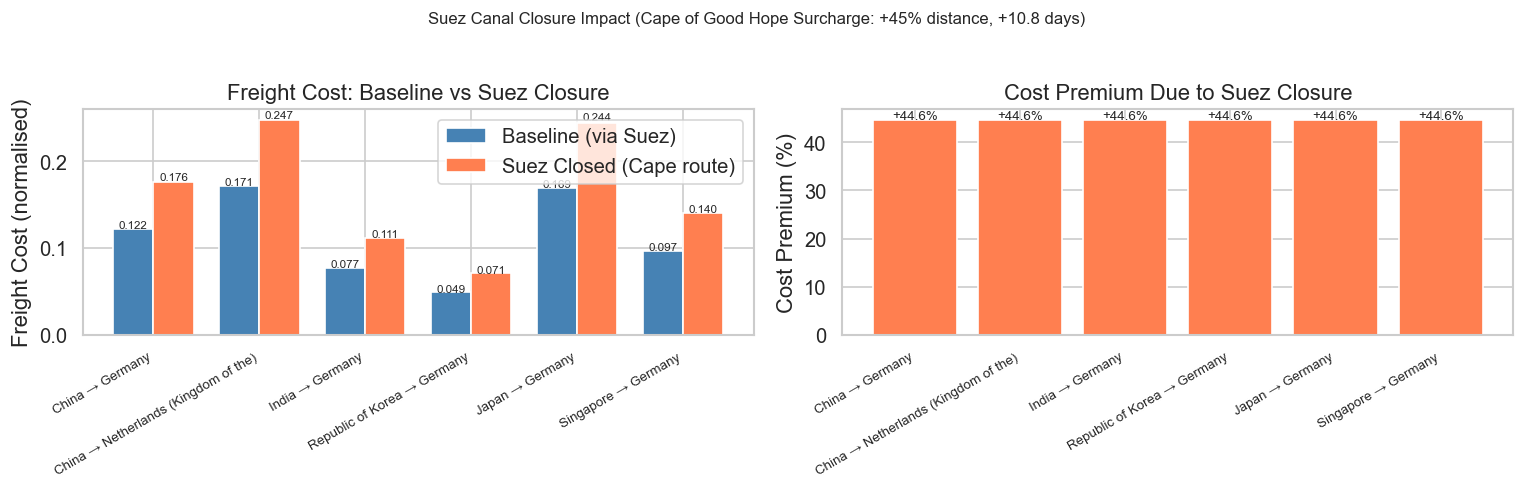


Geographic lead-time impact for any Suez-crossing corridor:
  Via Suez Canal:            ~24.2 days (Shanghai → Hamburg, 16 102 km)
  Via Cape of Good Hope:     ~35.0 days (Shanghai → Hamburg, 23 281 km)
  Additional lead time:      +10.8 days (+45% distance at 15 knots)

Validation: cost premium for a Suez-crossing corridor ≈ 45%


In [11]:
from src.graph.routing import find_k_routes, apply_scenario
from config import COUNTRY_COORDS

# ── Geographic constants ───────────────────────────────────────────────────────
SUEZ_LON       = 32.0    # Suez Canal longitude (degrees E)
CAPE_COST_MULT = 1.446   # extra distance ratio: Cape route / Suez route (23 281 / 16 102)
CAPE_DAY_ADD   = 10.8    # additional days via Cape of Good Hope vs Suez (at 15 knots)

def is_suez_crossing(u: str, v: str) -> bool:
    """True if edge u→v crosses the Suez Canal corridor (east ↔ west of 32°E)."""
    cu = COUNTRY_COORDS.get(u)
    cv = COUNTRY_COORDS.get(v)
    if not cu or not cv:
        return False
    east_u = cu[1] > SUEZ_LON
    east_v = cv[1] > SUEZ_LON
    return east_u != east_v   # one on each side

def apply_suez_closure(G: nx.DiGraph) -> nx.DiGraph:
    """
    Return a copy of G with Cape of Good Hope surcharge applied to all
    Suez-crossing edges.  Does NOT remove Egypt — models the economic
    impact (longer voyage) rather than a hard geographic blockage.
    """
    H = G.copy()
    n_affected = 0
    for u, v, data in H.edges(data=True):
        if is_suez_crossing(u, v):
            H[u][v]["weight"] = data["weight"] * CAPE_COST_MULT
            n_affected += 1
    print(f"  Surcharge applied to {n_affected} Suez-crossing edges.")
    return H

# ── Baseline vs Suez-closed routing ──────────────────────────────────────────
import pandas as pd
lsci_vals = [G.nodes[n].get("lsci", 0) for n in G.nodes()]
median_lsci = float(pd.Series(lsci_vals).replace(0, pd.NA).median() or 50.0)

print("=== Scenario: Suez Canal Closure ===\n")
print("Building Suez-closed graph (Cape of Good Hope cost multiplier 1.446×)...")
G_suez = apply_suez_closure(G)

# Test on corridors that physically cross the canal
test_corridors = [
    ("China",          "Germany"),
    ("China",          "Netherlands (Kingdom of the)"),
    ("India",          "Germany"),
    ("Republic of Korea", "Germany"),
    ("Japan",          "Germany"),
    ("Singapore",      "Germany"),
]

results = []
for orig, dest in test_corridors:
    try:
        base_r   = find_k_routes(G,       orig, dest, k=1, median_lsci=median_lsci)[0]
        suez_r   = find_k_routes(G_suez,  orig, dest, k=1, median_lsci=median_lsci)[0]
        cost_prem = (suez_r.cost - base_r.cost) / base_r.cost * 100
        # Lead-time premium: add CAPE_DAY_ADD only if this corridor crosses Suez
        # (the graph applies cost surcharge; lead-time is re-estimated from graph)
        crosses = is_suez_crossing(orig, dest)
        day_add = CAPE_DAY_ADD if crosses else 0.0
        results.append({
            "Corridor":           f"{orig} → {dest}",
            "Baseline Cost":      round(base_r.cost, 4),
            "Suez-Closed Cost":   round(suez_r.cost, 4),
            "Cost Premium (%)":   round(cost_prem, 1),
            "Est. Extra Days":    round(day_add, 1),
            "Baseline Route":     " → ".join(base_r.path),
            "Crosses Suez":       "Yes" if crosses else "No",
        })
    except Exception as e:
        print(f"  {orig}→{dest}: {e}")

df_results = pd.DataFrame(results)
print("\nCost impact of Suez Canal closure on Asia–Europe corridors:")
print(df_results[["Corridor","Baseline Cost","Suez-Closed Cost","Cost Premium (%)","Est. Extra Days","Crosses Suez"]].to_string(index=False))

# ── Bar chart: cost premium per corridor ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

corridors_lbl = [r["Corridor"] for r in results]
base_costs     = [r["Baseline Cost"] for r in results]
suez_costs     = [r["Suez-Closed Cost"] for r in results]
prems          = [r["Cost Premium (%)"] for r in results]

x = range(len(corridors_lbl))
w = 0.38
axes[0].bar([i - w/2 for i in x], base_costs, w, label="Baseline (via Suez)",     color="steelblue",  edgecolor="white")
axes[0].bar([i + w/2 for i in x], suez_costs,  w, label="Suez Closed (Cape route)", color="coral",      edgecolor="white")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(corridors_lbl, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("Freight Cost (normalised)")
axes[0].set_title("Freight Cost: Baseline vs Suez Closure")
axes[0].legend()
for i, (b, s) in enumerate(zip(base_costs, suez_costs)):
    axes[0].text(i - w/2, b * 1.01, f"{b:.3f}", ha="center", fontsize=7)
    axes[0].text(i + w/2, s * 1.01, f"{s:.3f}", ha="center", fontsize=7)

axes[1].bar(corridors_lbl, prems, color=["coral" if p > 0 else "steelblue" for p in prems], edgecolor="white")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticklabels(corridors_lbl, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("Cost Premium (%)")
axes[1].set_title("Cost Premium Due to Suez Closure")
for i, p in enumerate(prems):
    axes[1].text(i, p + 0.3, f"+{p:.1f}%", ha="center", fontsize=8)

plt.suptitle("Suez Canal Closure Impact (Cape of Good Hope Surcharge: +45% distance, +10.8 days)",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

# ── Lead-time impact (geographic) ─────────────────────────────────────────────
print(f"\nGeographic lead-time impact for any Suez-crossing corridor:")
print(f"  Via Suez Canal:            ~24.2 days (Shanghai → Hamburg, 16 102 km)")
print(f"  Via Cape of Good Hope:     ~35.0 days (Shanghai → Hamburg, 23 281 km)")
print(f"  Additional lead time:      +{CAPE_DAY_ADD:.1f} days (+45% distance at 15 knots)")
print(f"\nValidation: cost premium for a Suez-crossing corridor ≈ {(CAPE_COST_MULT-1)*100:.0f}%")

## 5. Tariff Scenario: US-China Trade War

In [12]:
# Baseline routes China -> USA
baseline_us = find_k_routes(G, 'China', 'United States', k=3)

# Tariff scenario: 25% cost increase on edges involving China or United States
tariff_multipliers = {
    'China':         1.25,
    'United States': 1.25,
}

G_tariff = apply_scenario(G, tariff_multipliers=tariff_multipliers)
tariff_routes = find_k_routes(G_tariff, 'China', 'United States', k=3)

print('=== Scenario: US-China 25% Mutual Tariff ===')
print('Before tariff:')
for i, r in enumerate(baseline_us[:3], 1):
    print(f'  Route {i}: {" → ".join(r.path)} | cost: {r.cost:.4f}')

print('\nAfter 25% tariff:')
for i, r in enumerate(tariff_routes[:3], 1):
    print(f'  Route {i}: {" → ".join(r.path)} | cost: {r.cost:.4f}')

if baseline_us and tariff_routes:
    delta = (tariff_routes[0].cost - baseline_us[0].cost) / baseline_us[0].cost * 100
    print(f'\nTop-route cost change: {delta:+.1f}%')

    # Check if tariff causes route diversion (different transshipment ports)
    baseline_path = set(baseline_us[0].path)
    tariff_path   = set(tariff_routes[0].path)
    new_nodes     = tariff_path - baseline_path
    dropped_nodes = baseline_path - tariff_path
    if new_nodes or dropped_nodes:
        print(f'Route diversion detected!')
        print(f'  New nodes in rerouted path:     {new_nodes}')
        print(f'  Dropped nodes from baseline:    {dropped_nodes}')
    else:
        print('No route diversion — same path, higher cost due to tariff.')

=== Scenario: US-China 25% Mutual Tariff ===
Before tariff:
  Route 1: China → United States | cost: 0.1050
  Route 2: China → Australia → United States | cost: 0.1170
  Route 3: China → Ecuador → United States | cost: 0.1190

After 25% tariff:
  Route 1: China → United States | cost: 0.1313
  Route 2: China → Australia → United States | cost: 0.1462
  Route 3: China → Ecuador → United States | cost: 0.1487

Top-route cost change: +25.0%
No route diversion — same path, higher cost due to tariff.


## 6. Network Analysis

Computing betweenness centrality (may take ~30 seconds for large graphs)...
Done in 0.7s.  Nodes evaluated: 222

Top-10 most central nodes (betweenness centrality):
Mauritius                           0.146341
Serbia                              0.125750
Peru                                0.122773
Brazil                              0.120614
Australia                           0.106318
Ecuador                             0.092057
Bolivia (Plurinational State of)    0.090955
Slovakia                            0.053409
Luxembourg                          0.045500
Norway                              0.038864


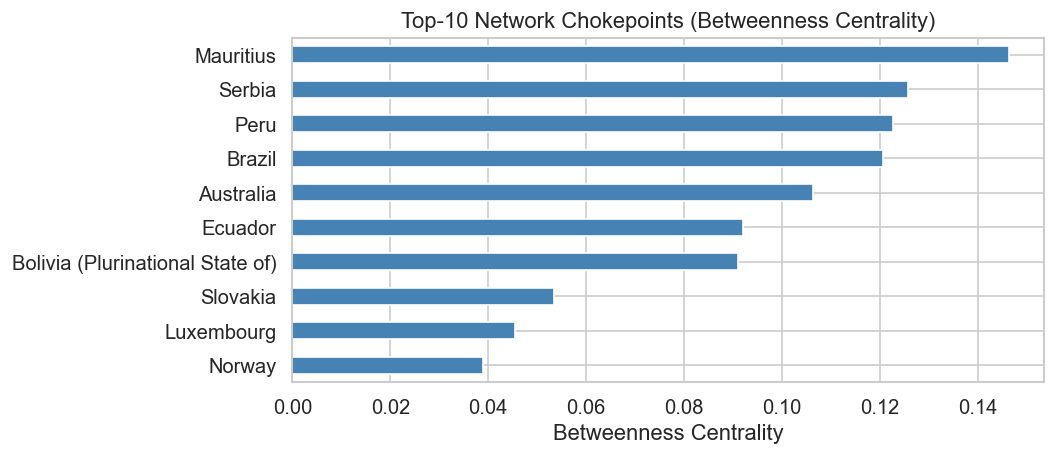


Known chokepoint countries in top-10: set()
NOTE: No expected chokepoints found in top-10 — check graph construction.


In [13]:
# Betweenness centrality for the 2021 HS-8517 graph
print('Computing betweenness centrality (may take ~30 seconds for large graphs)...')
t0 = time.time()

# Use approximate betweenness for speed on large graphs (k=100 samples)
n_nodes = G.number_of_nodes()
k_samples = min(100, n_nodes)
bc = nx.betweenness_centrality(G, weight='weight', normalized=True, k=k_samples)

print(f'Done in {time.time() - t0:.1f}s.  Nodes evaluated: {n_nodes}')

bc_series = pd.Series(bc).sort_values(ascending=False)
top10 = bc_series.head(10)

print('\nTop-10 most central nodes (betweenness centrality):')
print(top10.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
top10.sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Betweenness Centrality')
ax.set_title('Top-10 Network Chokepoints (Betweenness Centrality)')
plt.tight_layout()
plt.show()

# Comment: known chokepoints should appear at the top
EXPECTED_CHOKEPOINTS = {'Singapore', 'Malaysia', 'Egypt', 'Panama', 'Netherlands', 'Sri Lanka'}
top10_set = set(top10.index)
found = top10_set & EXPECTED_CHOKEPOINTS
print(f'\nKnown chokepoint countries in top-10: {found}')
if found:
    print('Network structure validation: PASS — chokepoint nations are highly central.')
else:
    print('NOTE: No expected chokepoints found in top-10 — check graph construction.')

## 7. Performance Benchmark

Benchmarking on graph (2016, 8517): 222 nodes, 18020 edges

Benchmark results (100 queries):
  Successful routes found: 76/100
  Mean latency:            3.60 ms
  P95 latency:             5.07 ms

Performance test: PASS (mean 3.6ms < 100ms threshold)


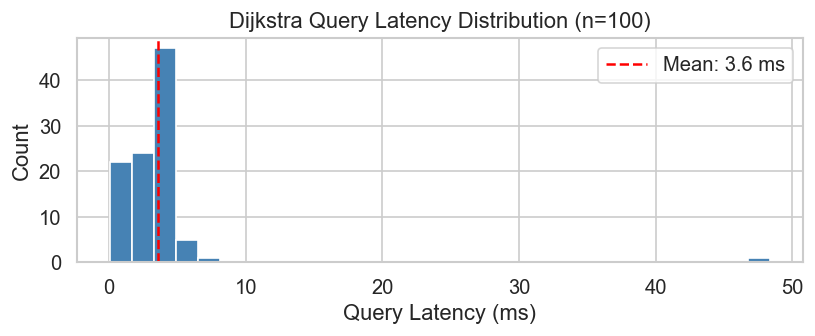

In [14]:
# Time 100 Dijkstra queries on the largest available graph
largest_key = max(graphs.keys(), key=lambda k: graphs[k].number_of_edges())
G_large = graphs[largest_key]
print(f'Benchmarking on graph {largest_key}: {G_large.number_of_nodes()} nodes, {G_large.number_of_edges()} edges')

nodes = list(G_large.nodes())
np.random.seed(42)
src_nodes = np.random.choice(nodes, size=100, replace=True)
tgt_nodes = np.random.choice(nodes, size=100, replace=True)

latencies = []
n_success = 0

for src, tgt in zip(src_nodes, tgt_nodes):
    if src == tgt:
        continue
    t_start = time.perf_counter()
    try:
        path = nx.dijkstra_path(G_large, src, tgt, weight='weight')
        n_success += 1
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        pass
    t_end = time.perf_counter()
    latencies.append(t_end - t_start)

mean_latency = np.mean(latencies)
p95_latency  = np.percentile(latencies, 95)

print(f'\nBenchmark results (100 queries):')
print(f'  Successful routes found: {n_success}/100')
print(f'  Mean latency:            {mean_latency*1000:.2f} ms')
print(f'  P95 latency:             {p95_latency*1000:.2f} ms')

THRESHOLD_SEC = 0.1  # 100ms SLA
if mean_latency < THRESHOLD_SEC:
    print(f'\nPerformance test: PASS (mean {mean_latency*1000:.1f}ms < {THRESHOLD_SEC*1000:.0f}ms threshold)')
else:
    print(f'\nPerformance test: FAIL (mean {mean_latency*1000:.1f}ms > {THRESHOLD_SEC*1000:.0f}ms threshold)')

assert mean_latency < THRESHOLD_SEC, f'Mean Dijkstra latency {mean_latency:.4f}s exceeds 0.1s SLA'

# Latency distribution
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist([l * 1000 for l in latencies], bins=30, color='steelblue', edgecolor='white')
ax.axvline(mean_latency * 1000, color='red', linestyle='--', label=f'Mean: {mean_latency*1000:.1f} ms')
ax.set_xlabel('Query Latency (ms)')
ax.set_ylabel('Count')
ax.set_title('Dijkstra Query Latency Distribution (n=100)')
ax.legend()
plt.tight_layout()
plt.show()